<a href="https://colab.research.google.com/github/saran-944/Projet_GPI_SD/blob/main/GPI_Project_Saran_DEMBELE.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Import Required Libraries

In [382]:
import numpy as np
import matplotlib.pyplot as plt
import cv2
import tifffile as tif
from scipy import ndimage

from PIL import Image
import importlib.util
import subprocess
import sys
import requests
from io import BytesIO

from skimage import io, transform
from skimage.feature import peak_local_max
from scipy.signal import correlate2d
from scipy.ndimage import gaussian_filter

import urllib.request
%pip install biopython
from Bio.PDB import PDBParser, PDBIO
from mpl_toolkits.mplot3d import Axes3D


# Install required package (run once)
%pip install mrcfile

import mrcfile

%pip install gdown

import gdown
import mrcfile
import os


## Importing and visualizing MRC file

Downloading...
From (original): https://drive.google.com/uc?id=1Qj30jSXcHEpkzE04cisbP6ljtnQ2Ausr
From (redirected): https://drive.google.com/uc?id=1Qj30jSXcHEpkzE04cisbP6ljtnQ2Ausr&confirm=t&uuid=a0b56468-20bd-4a1f-ad3c-4408b106b13f
To: /content/map.mrc
100%|██████████| 228M/228M [00:02<00:00, 76.7MB/s]
/usr/local/lib/python3.12/dist-packages/mrcfile/mrcinterpreter.py:206: RuntimeWarning: Map ID string not found - not an MRC file, or file is corrupt
  warnings.warn(msg, RuntimeWarning)
/usr/local/lib/python3.12/dist-packages/mrcfile/mrcinterpreter.py:216: RuntimeWarning: Unrecognised machine stamp: 0x00 0x00 0x00 0x00
  warnings.warn(str(err), RuntimeWarning)



File size: 217.27 MB
First 4 bytes: b'\xfc\x1c\x00\x00'
✓ File appears valid

Loading MRC file...
✓ MRC loaded successfully

MRC DATA INFO
Shape: (7676, 7420)
Dtype: float32
Min/Max: -3.31172 41.723225

Detected: single 2D image


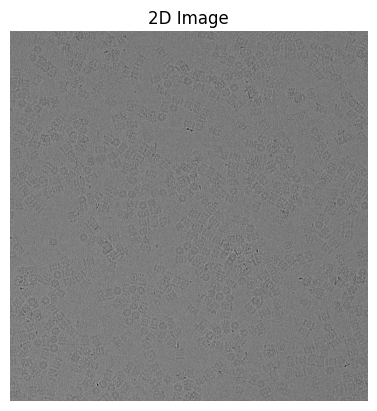

In [383]:
file_id = "1Qj30jSXcHEpkzE04cisbP6ljtnQ2Ausr"
output = "map.mrc"

print("Downloading MRC file...")
gdown.download(id=file_id, output=output, quiet=False)


file_size = os.path.getsize(output)
print(f"\nFile size: {file_size / (1024**2):.2f} MB")

with open(output, "rb") as f:
    header = f.read(4)

print("First 4 bytes:", header)

if header.startswith(b"<"):
    raise ValueError("❌ Downloaded file is HTML, not MRC. Check sharing permissions.")

if file_size < 10000:
    raise ValueError("❌ File too small — likely incorrect download.")

print("✓ File appears valid")

print("\nLoading MRC file...")

with mrcfile.open(output, permissive=True) as mrc:
    if mrc.data is None:
        raise ValueError("❌ MRC file contains no readable data")
    data = mrc.data.copy()

print("✓ MRC loaded successfully")

print("\n" + "="*60)
print("MRC DATA INFO")
print("="*60)
print("Shape:", data.shape)
print("Dtype:", data.dtype)
print("Min/Max:", data.min(), data.max())


if data.ndim == 3:
    print("\nDetected: 3D volume")

    z, y, x = np.array(data.shape) // 2

    # ------------------------------------------
    # CENTRAL SLICES (RAW)
    # ------------------------------------------
    fig, axes = plt.subplots(1, 3, figsize=(15, 5))

    slices = [
        (data[z, :, :], "XY slice"),
        (data[:, y, :], "XZ slice"),
        (data[:, :, x], "YZ slice"),
    ]

    for ax, (img, title) in zip(axes, slices):
        vmin = np.percentile(img, 5)
        vmax = np.percentile(img, 95)
        ax.imshow(img, cmap='gray', vmin=vmin, vmax=vmax)
        ax.set_title(title)
        ax.axis('off')

    plt.tight_layout()
    plt.show()

    print("\nGenerating summed projections...")

    proj_xy = np.sum(data, axis=0)
    proj_xz = np.sum(data, axis=1)
    proj_yz = np.sum(data, axis=2)

    fig, axes = plt.subplots(1, 3, figsize=(15, 5))

    projections = [
        (proj_xy, "XY Projection (sum Z)"),
        (proj_xz, "XZ Projection (sum Y)"),
        (proj_yz, "YZ Projection (sum X)")
    ]

    for ax, (proj, title) in zip(axes, projections):
        vmin = np.percentile(proj, 5)
        vmax = np.percentile(proj, 95)
        ax.imshow(proj, cmap='gray', vmin=vmin, vmax=vmax)
        ax.set_title(title)
        ax.axis('off')

    plt.tight_layout()
    plt.show()

elif data.ndim == 2:
    print("\nDetected: single 2D image")

    vmin = np.percentile(data, 5)
    vmax = np.percentile(data, 95)

    plt.imshow(data, cmap='gray', vmin=vmin, vmax=vmax)
    plt.title("2D Image")
    plt.axis('off')
    plt.show()

else:
    print("\n⚠️ Unrecognized format")

# Preprocess the Image

## Binning

Binning added


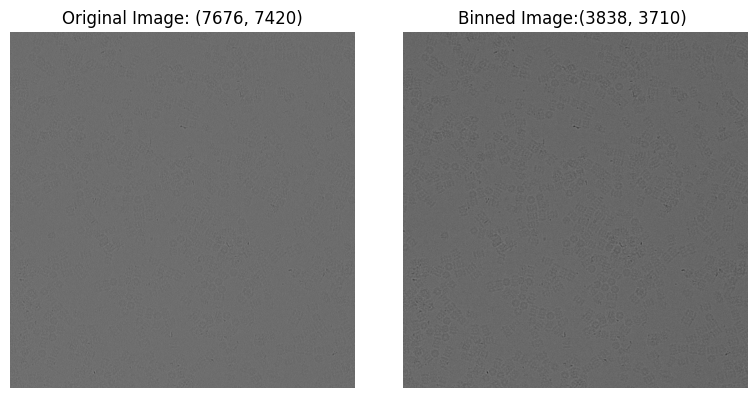

In [386]:
def binning(image, factor):
    h, w = image.shape
    new_h = h // factor
    new_w = w // factor


    binned = image[:new_h*factor, :new_w*factor].reshape(new_h, factor, new_w, factor)
    binned = binned.mean(axis=(1, 3)).astype(image.dtype)
    return binned

print(f"Binning added")

factor = 2
binned_data = binning(data, factor)

plt.figure(figsize=(8, 4))
plt.subplot(1, 2, 1)
plt.imshow(data, cmap='gray')
plt.title(f"Original Image: {data.shape}")
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(binned_data, cmap='gray')
plt.title(f"Binned Image:{binned_data.shape} ")
plt.axis('off')

plt.tight_layout()
plt.show()

## Normalize the image

Normalization added


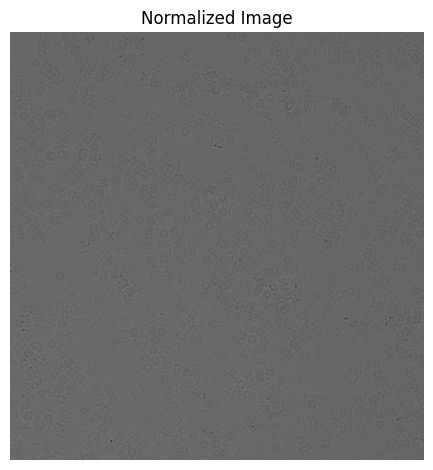

In [387]:
def normalize_zscore(image):
  mean = np.mean(image)
  std = np.std(image)
  return (image - mean) / std

print(f"Normalization added")

normalized = normalize_zscore(binned_data)

plt.imshow(normalized, cmap='gray')
plt.title(f"Normalized Image")
plt.axis('off')

plt.tight_layout()
plt.show()


## Padding

Padding added


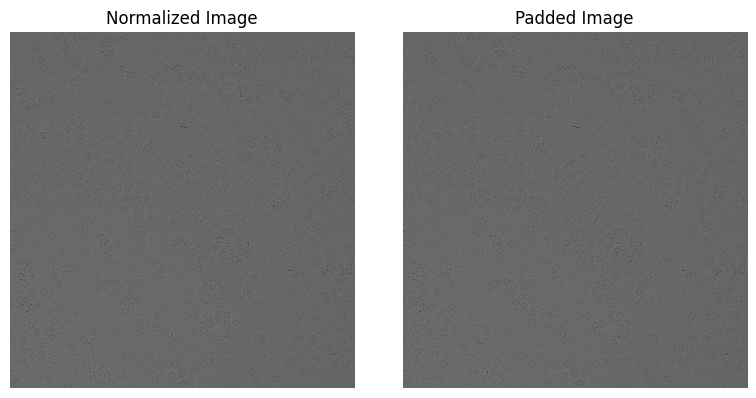

In [388]:
def padding(image, factor):
  h, w = image.shape

  pad_h = (factor - h % factor) % factor
  pad_w = (factor - w % factor) % factor

  padded_image = np.pad(image, ((0, pad_h), (0, pad_w)), mode='constant', constant_values=0)
  return padded_image

print(f"Padding added")

padded = padding(normalized, 2)

plt.figure(figsize=(8, 4))
plt.subplot(1, 2, 1)
plt.imshow(normalized, cmap='gray')
plt.title(f"Normalized Image")
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(padded, cmap='gray')
plt.title(f"Padded Image")
plt.axis('off')

plt.tight_layout()
plt.show()

## Check image format that the CC Function accept

In [389]:
print(f"Actual Format : {padded.shape}, Type : {padded.dtype}")
if not np.issubdtype(padded.dtype, np.floating):
  final_image = padded.astype(np.float32)
else:
  final_image = padded

Actual Format : (3838, 3710), Type : float32


## Denoising with Gaussian filter

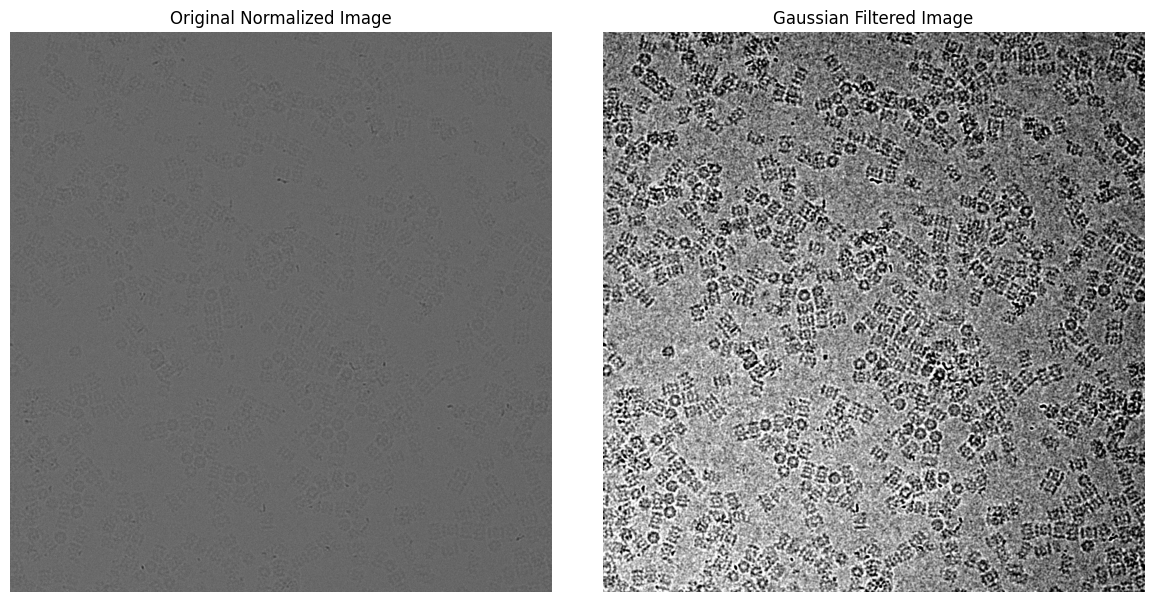

Original Normalized Image shape: (3838, 3710), dtype: float32
Gaussian Filtered Image shape: (3838, 3710), dtype: float32


In [392]:
img_denoised = gaussian_filter(padded, sigma=4)

img_ready_for_ncc = normalize_zscore(img_denoised)
img_ready = np.clip(img_ready_for_ncc, -2, 2)

plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.imshow(normalized, cmap='gray')
plt.title('Original Normalized Image')
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(img_ready, cmap='gray')
plt.title('Gaussian Filtered Image')
plt.axis('off')

plt.tight_layout()
plt.show()

print(f"Original Normalized Image shape: {normalized.shape}, dtype: {normalized.dtype}")
print(f"Gaussian Filtered Image shape: {img_ready.shape}, dtype: {img_ready.dtype}")


# Prepare the Template

## Import the PDB


📥 FETCHING PDB STRUCTURE: 6BDF
✓ Successfully downloaded 3885327 bytes
✓ Saved to 6BDF.pdb

🔬 STRUCTURE INFORMATION

Structure ID: 6BDF
Number of models: 1
Number of chains: 28

Chain A:
  - Residues: 242
  - Atoms: 1741

Chain B:
  - Residues: 232
  - Atoms: 1572

Chain C:
  - Residues: 242
  - Atoms: 1741

Chain D:
  - Residues: 232
  - Atoms: 1572

Chain E:
  - Residues: 242
  - Atoms: 1741

Chain F:
  - Residues: 232
  - Atoms: 1572

Chain G:
  - Residues: 242
  - Atoms: 1741

Chain H:
  - Residues: 232
  - Atoms: 1572

Chain I:
  - Residues: 242
  - Atoms: 1741

Chain J:
  - Residues: 232
  - Atoms: 1572

Chain K:
  - Residues: 242
  - Atoms: 1741

Chain L:
  - Residues: 232
  - Atoms: 1572

Chain M:
  - Residues: 242
  - Atoms: 1741

Chain N:
  - Residues: 232
  - Atoms: 1572

Chain O:
  - Residues: 242
  - Atoms: 1741

Chain P:
  - Residues: 232
  - Atoms: 1572

Chain Q:
  - Residues: 242
  - Atoms: 1741

Chain R:
  - Residues: 232
  - Atoms: 1572

Chain S:
  - Residues: 242
  

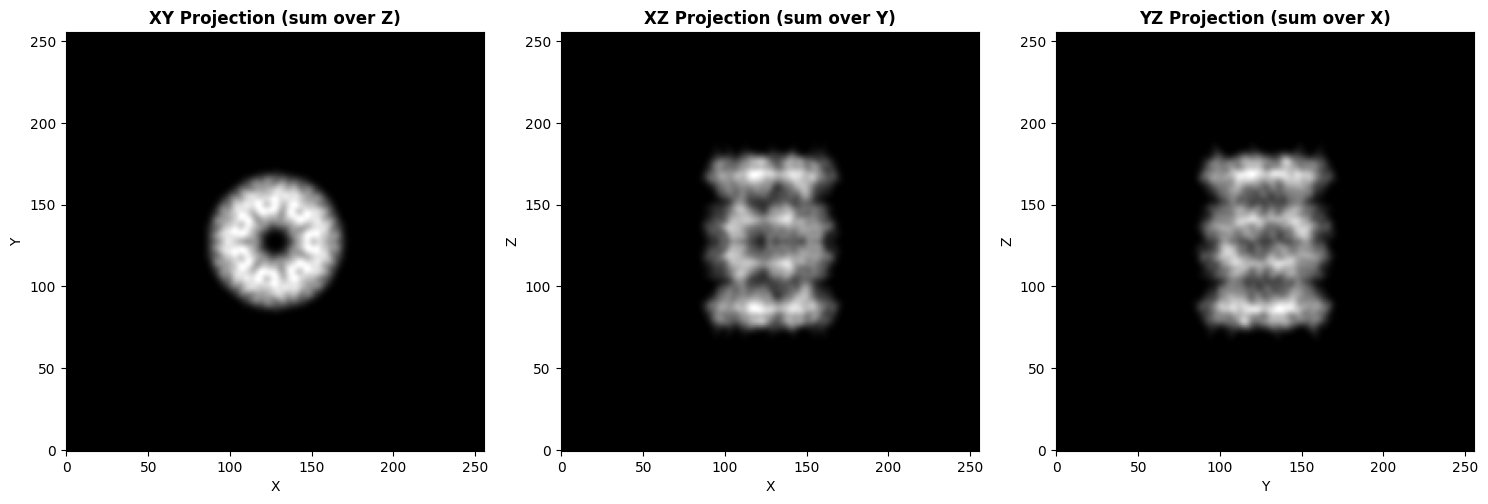


Summed Density Projections:
  - Pixel intensity = number of atoms projected into that pixel
  - Brighter = higher density
  - Approximates ideal projection images (no noise, no CTF)


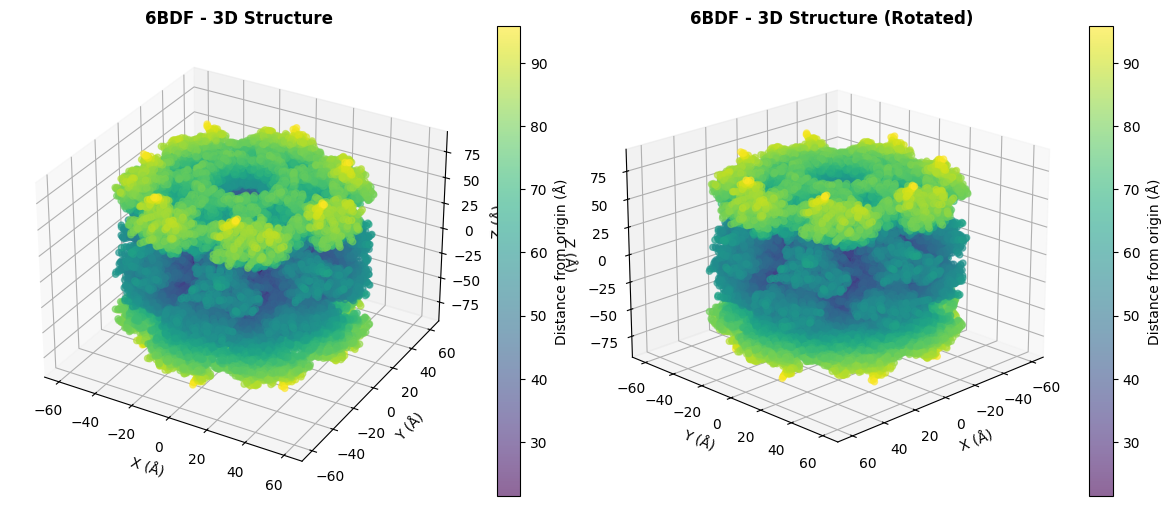

In [393]:
print("\n" + "="*70)
print("📥 FETCHING PDB STRUCTURE: 6BDF")
print("="*70)

pdb_id = "6BDF"
pdb_url = f"https://files.rcsb.org/download/{pdb_id}.pdb"

try:
    print(f"Downloading {pdb_id} from RCSB PDB...")
    with urllib.request.urlopen(pdb_url, timeout=10) as response:
        pdb_content = response.read().decode('utf-8')
    print(f"✓ Successfully downloaded {len(pdb_content)} bytes")

    # Save to file
    pdb_file = f"{pdb_id}.pdb"
    with open(pdb_file, 'w') as f:
        f.write(pdb_content)
    print(f"✓ Saved to {pdb_file}")

    # Parse the PDB file
    parser = PDBParser(QUIET=True)
    structure = parser.get_structure(pdb_id, pdb_file)

    print("\n" + "="*70)
    print("🔬 STRUCTURE INFORMATION")
    print("="*70)

    # Extract information
    model = structure[0]
    chains = list(model.get_chains())

    print(f"\nStructure ID: {pdb_id}")
    print(f"Number of models: {len(structure)}")
    print(f"Number of chains: {len(chains)}")

    for chain in chains:
        residues = list(chain.get_residues())
        atoms = list(chain.get_atoms())
        print(f"\nChain {chain.id}:")
        print(f"  - Residues: {len(residues)}")
        print(f"  - Atoms: {len(atoms)}")

    # Extract atomic coordinates
    print("\n" + "="*70)
    print("🧬 ATOMIC COORDINATES FROM 6BDF")
    print("="*70)

    all_atoms = []
    for chain in model.get_chains():
        for residue in chain.get_residues():
            for atom in residue.get_atoms():
                coord = atom.get_coord()
                all_atoms.append({
                    'name': atom.name,
                    'residue': residue.resname,
                    'residue_id': residue.id[1],
                    'x': coord[0],
                    'y': coord[1],
                    'z': coord[2],
                    'b_factor': atom.bfactor
                })

    print(f"Total atoms: {len(all_atoms)}")
    print(f"\nFirst 10 atoms:")
    print(f"{'Atom':6} {'Residue':8} {'Res#':5} {'X (Å)':10} {'Y (Å)':10} {'Z (Å)':10} {'B-factor':10}")
    print("-" * 60)
    for atom in all_atoms[:10]:
        print(f"{atom['name']:6} {atom['residue']:8} {atom['residue_id']:5d} {atom['x']:10.3f} {atom['y']:10.3f} {atom['z']:10.3f} {atom['b_factor']:10.2f}")

    # Extract coordinates for visualization
    coords = np.array([[atom['x'], atom['y'], atom['z']] for atom in all_atoms])

    print(f"\nCoordinate statistics:")
    print(f"  X range: [{coords[:, 0].min():.3f}, {coords[:, 0].max():.3f}] Å")
    print(f"  Y range: [{coords[:, 1].min():.3f}, {coords[:, 1].max():.3f}] Å")
    print(f"  Z range: [{coords[:, 2].min():.3f}, {coords[:, 2].max():.3f}] Å")

    print("\n" + "="*70)
    print("🎯 CREATING DENSITY-BASED 2D PROJECTIONS (SUMMED GRAYSCALE)")
    print("="*70)

    # Center coordinates
    coords_centered = coords - coords.mean(axis=0)

    # Resolution of projection image
    img_size = 256  # pixels
    padding = 5     # Å padding around structure

    # Function to create summed projection
    def create_projection(coord1, coord2, limit, box_size_px=256, sigma=2.0):
        # Determine bounds
        # La limite de l'image est la moitié de la largeur physique
        limit = physical_half_width

        # On crée l'histogramme avec des limites fixes centrées sur 0
        H, xedges, yedges = np.histogram2d(
            coord1, coord2,
            bins=box_size_px, # Explicitly use box_size_px for bins
            range=[[-limit, limit], [-limit, limit]]
        )

        # Application du filtre gaussien (le flou de résolution)
        H_blurred = gaussian_filter(H, sigma=sigma)

        # Normalize for display (normalize the blurred image)
        if H_blurred.max() > 0: # Avoid division by zero if H_blurred is all zeros
            H_normalized = H_blurred / H_blurred.max()
        else:
            H_normalized = np.zeros_like(H_blurred) # If H_blurred is all zeros, keep it as zeros

        return H_normalized # Return the blurred and normalized image

    # Create projections
    proj_xy = create_projection(coords_centered[:, 0], coords_centered[:, 1], limit=physical_half_width, box_size_px=256, sigma=2.0)
    proj_xz = create_projection(coords_centered[:, 0], coords_centered[:, 2], limit=physical_half_width, box_size_px=256, sigma=2.0)
    proj_yz = create_projection(coords_centered[:, 1], coords_centered[:, 2], limit=physical_half_width, box_size_px=256, sigma=2.0)

    # Plot projections
    fig, axes = plt.subplots(1, 3, figsize=(15, 5))

    # XY projection
    axes[0].imshow(proj_xy.T, cmap='gray', origin='lower')
    axes[0].set_title('XY Projection (sum over Z)', fontweight='bold')
    axes[0].set_xlabel('X')
    axes[0].set_ylabel('Y')

    # XZ projection
    axes[1].imshow(proj_xz.T, cmap='gray', origin='lower')
    axes[1].set_title('XZ Projection (sum over Y)', fontweight='bold')
    axes[1].set_xlabel('X')
    axes[1].set_ylabel('Z')

    # YZ projection
    axes[2].imshow(proj_yz.T, cmap='gray', origin='lower')
    axes[2].set_title('YZ Projection (sum over X)', fontweight='bold')
    axes[2].set_xlabel('Y')
    axes[2].set_ylabel('Z')

    plt.tight_layout()
    plt.show()

    print("\nSummed Density Projections:")
    print("  - Pixel intensity = number of atoms projected into that pixel")
    print("  - Brighter = higher density")
    print("  - Approximates ideal projection images (no noise, no CTF)")

    # 3D visualization
    fig = plt.figure(figsize=(12, 5))

    # 3D scatter plot
    ax4 = fig.add_subplot(1, 2, 1, projection='3d')
    scatter = ax4.scatter(coords_centered[:, 0], coords_centered[:, 1], coords_centered[:, 2],
                          c=np.linalg.norm(coords_centered, axis=1), cmap='viridis', s=20, alpha=0.6)
    ax4.set_xlabel('X (Å)', fontsize=10)
    ax4.set_ylabel('Y (Å)', fontsize=10)
    ax4.set_zlabel('Z (Å)', fontsize=10)
    ax4.set_title(f'{pdb_id} - 3D Structure', fontsize=12, fontweight='bold')
    plt.colorbar(scatter, ax=ax4, label='Distance from origin (Å)')

    # 3D scatter plot - rotated view
    ax5 = fig.add_subplot(1, 2, 2, projection='3d')
    scatter2 = ax5.scatter(coords_centered[:, 0], coords_centered[:, 1], coords_centered[:, 2],
                           c=np.linalg.norm(coords_centered, axis=1), cmap='viridis', s=20, alpha=0.6)
    ax5.view_init(elev=20, azim=45)  # Different viewing angle
    ax5.set_xlabel('X (Å)', fontsize=10)
    ax5.set_ylabel('Y (Å)', fontsize=10)
    ax5.set_zlabel('Z (Å)', fontsize=10)
    ax5.set_title(f'{pdb_id} - 3D Structure (Rotated)', fontsize=12, fontweight='bold')
    plt.colorbar(scatter2, ax=ax5, label='Distance from origin (Å)')

    plt.tight_layout()
    plt.show()


except urllib.error.URLError as e:
    print(f"❌ Error downloading PDB file: {e}")
    print("   Make sure you have internet connection")
except Exception as e:
    print(f"❌ Error: {type(e).__name__}: {e}")

## Make Projections

### Check Pixel Size

In [394]:
box_size_px = 256
manual_pixel_size = 1.4

physical_width = box_size_px * manual_pixel_size
physical_half_width = physical_width / 2

pdb_pixel_size = (physical_half_width * 2) / box_size_px


if np.isclose(pdb_pixel_size, manual_pixel_size):
    print(f"The PDB template scale matches the manual pixel size ({manual_pixel_size} A/px).")
else:
    print("Mismatch detected.")

The PDB template scale matches the manual pixel size (1.4 A/px).


### Normalization

# NCC

### NCC sur le Crop Amélioré
Calcul de la carte de score pour localiser les particules.

NCC calculation finished


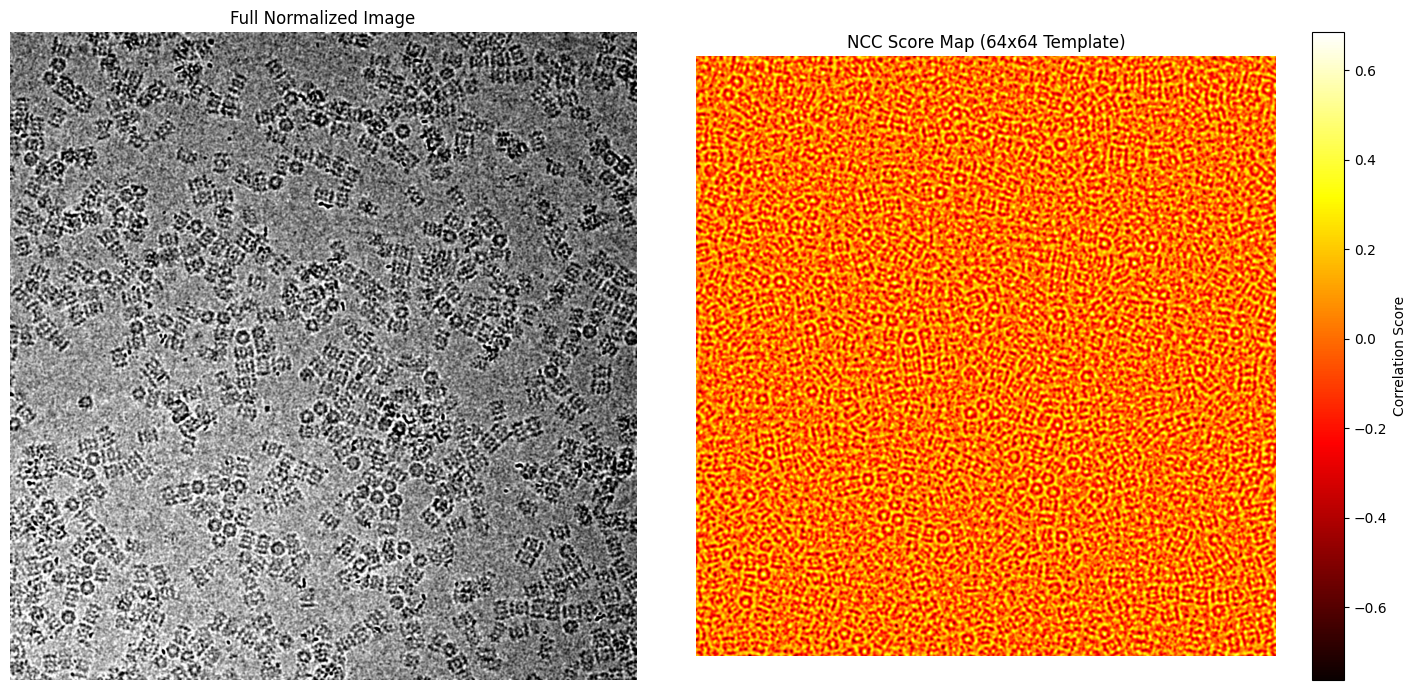

Max NCC Score detected: 0.6852


In [398]:
def f_ncc(image, template):

    result = cv2.matchTemplate(image.astype(np.float32), template.astype(np.float32), cv2.TM_CCOEFF_NORMED)
    return result

template_small = transform.resize(proj_xy, (64, 64)).astype(np.float32)

ncc_result = fast_ncc( img_ready, template_small)
print("NCC calculation finished")

plt.figure(figsize=(15, 7))

plt.subplot(1, 2, 1)
plt.imshow(img_ready, cmap='gray')
plt.title('Full Normalized Image')
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(ncc_result, cmap='hot')
plt.title('NCC Score Map (64x64 Template)')
plt.colorbar(label='Correlation Score')
plt.axis('off')

plt.tight_layout()
plt.show()

print(f"Max NCC Score detected: {ncc_result.max():.4f}")

## Optimize the shift (extraction of peaks) and the threshold

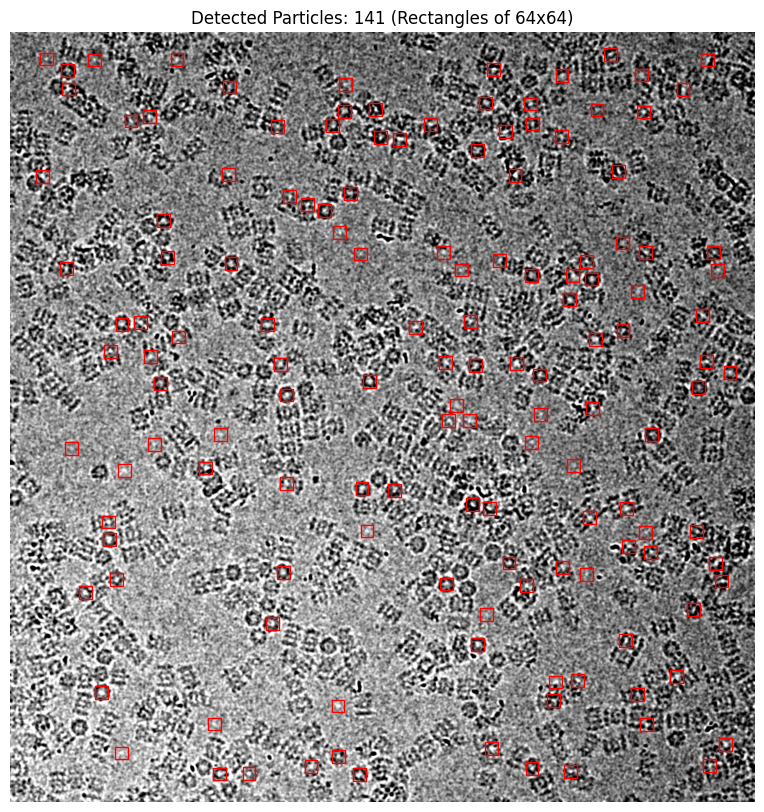

In [400]:
import matplotlib.patches as patches

tmp_h, tmp_w = template_small.shape


min_distance_for_peaks = tmp_h
threshold = 0.5 # Threshold for peak detection
peaks = peak_local_max(ncc_result, min_distance=min_distance_for_peaks, threshold_abs=threshold)

plt.figure(figsize=(10, 10))
plt.imshow(img_ready, cmap='gray')
ax = plt.gca()

for peak in peaks:
    y, x = peak
    rect = patches.Rectangle((x, y), tmp_w, tmp_h, linewidth=1, edgecolor='r', facecolor='none')
    ax.add_patch(rect)

plt.title(f'Detected Particles: {len(peaks)} (Rectangles of {tmp_h}x{tmp_w})')
plt.axis('off')
plt.show()

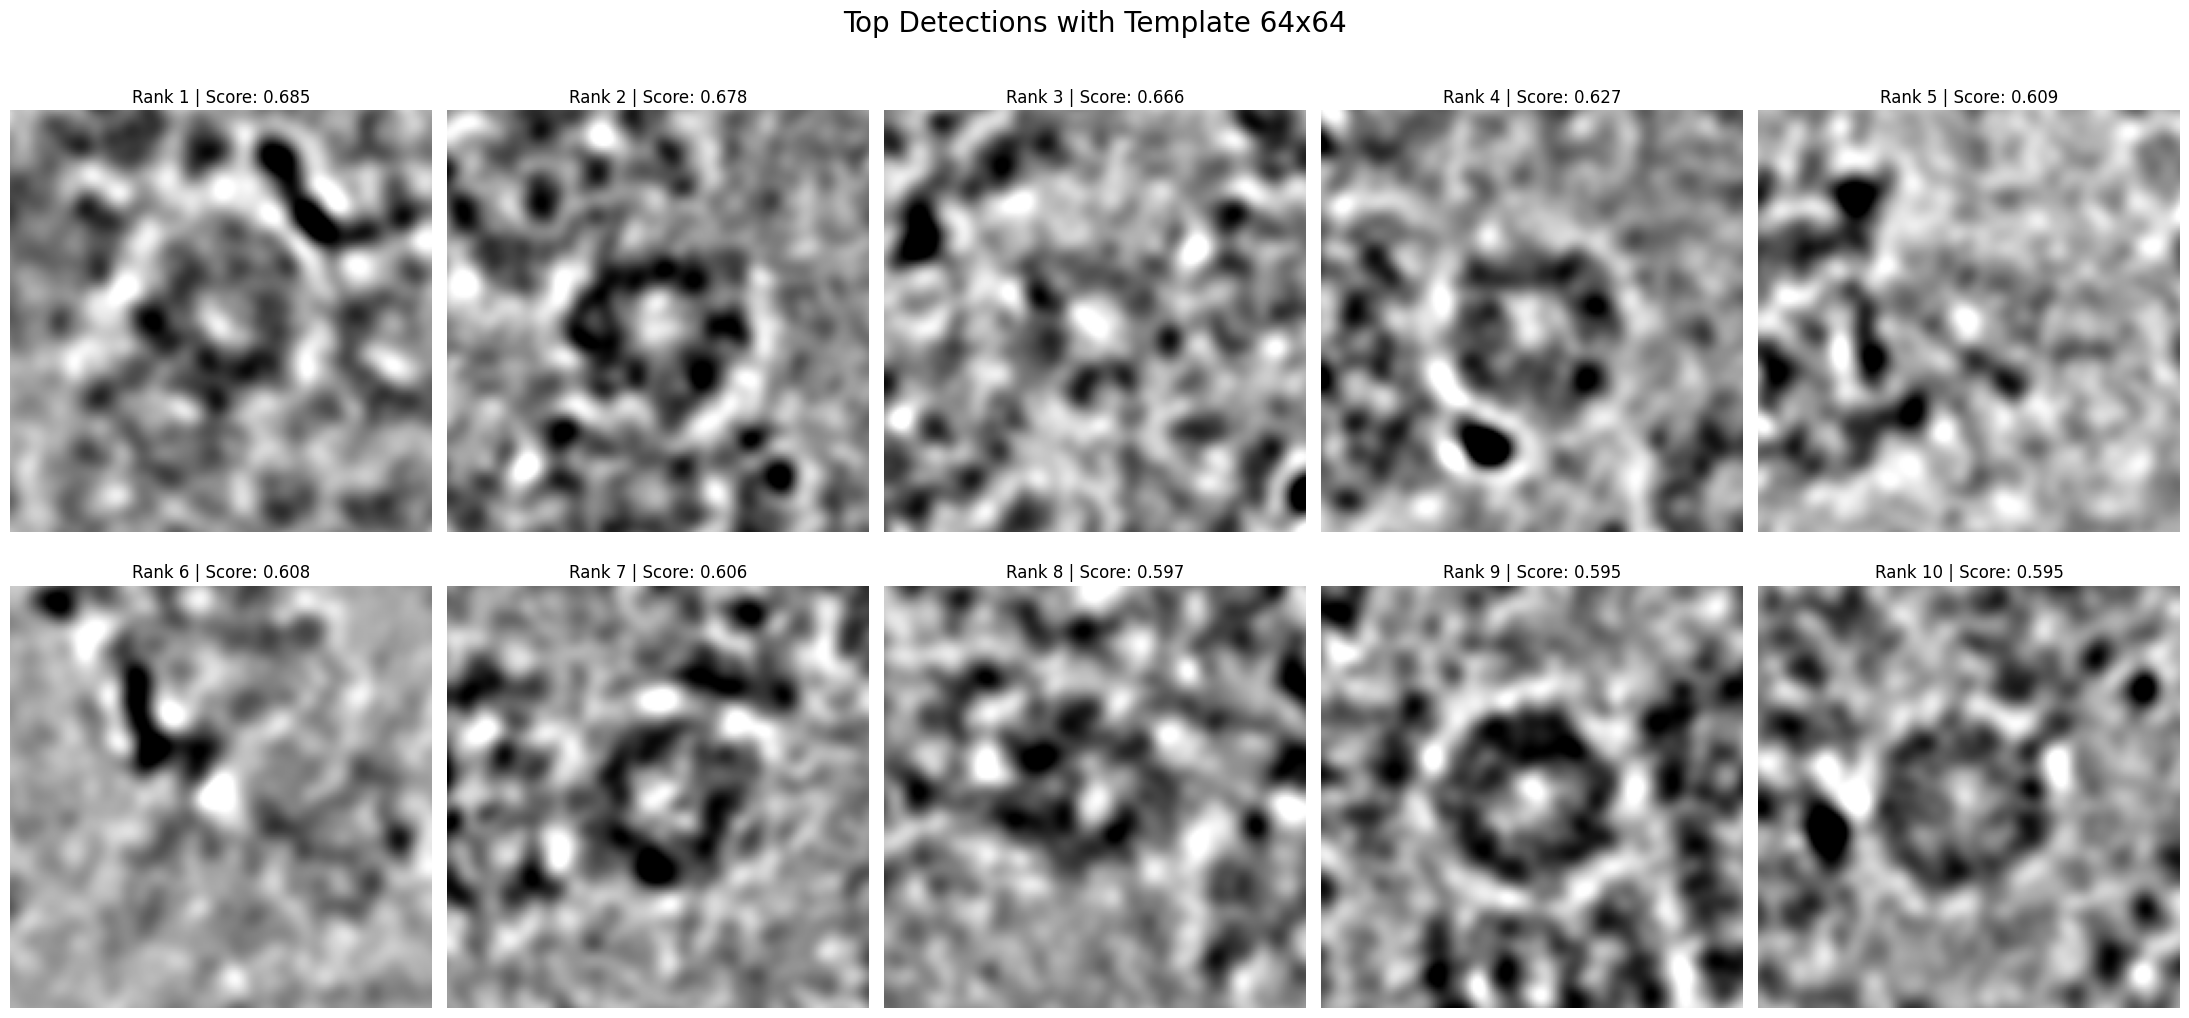

In [401]:
# Extraction
peak_scores = ncc_result[peaks[:, 0], peaks[:, 1]]
sorted_indices = np.argsort(peak_scores)[::-1]
sorted_peaks = peaks[sorted_indices]

num_inspect = 10
inspect_peaks = sorted_peaks[:min(num_inspect, len(sorted_peaks))]

fig, axes = plt.subplots(2, 5, figsize=(22, 10))
axes = axes.flatten()


shift_y, shift_x = np.array(template_small.shape) // 2

for i, peak in enumerate(inspect_peaks):
    y, x = peak
    box = 100 # Size of the crop around the detected particle
    cy, cx = y + shift_y, x + shift_x

    # Use img_ready_for_ncc for cropping, as it's the pre-processed image
    y1, y2 = int(max(0, cy - box)), int(min(img_ready_for_ncc.shape[0], cy + box))
    x1, x2 = int(max(0, cx - box)), int(min(img_ready_for_ncc.shape[1], cx + box))

    crop = img_ready_for_ncc[y1:y2, x1:x2]

    axes[i].imshow(crop, cmap='gray', vmin=np.percentile(crop, 1), vmax=np.percentile(crop, 99))
    axes[i].set_title(f"Rank {i+1} | Score: {ncc_result[y, x]:.3f}", fontsize=12)
    axes[i].axis('off')

plt.tight_layout()
plt.suptitle(f'Top Detections with Template {template_small.shape[0]}x{template_small.shape[1]}', fontsize=20, y=1.05)
plt.show()